# U-Net – Clothing Instance Segmentation
Architecture: CNN encoder (ResNet-34 backbone, trained from scratch) + symmetric decoder with skip connections.
Post-processing: connected component analysis → bounding boxes → majority-vote class labels.

**Metrics reported:**
- Segmentation: mIoU (per class + macro avg), Dice coefficient
- Detection: COCO-style mAP@[0.5:0.95]
- Per-class: ROC-AUC, F1-score, ROC curves

In [1]:
import os, ast
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from PIL import Image
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/train_annotations.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/val_annotations.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/test_annotations.csv")

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
train_df.head()

Train: 39241 | Val: 8386 | Test: 8453


,image,category,bbox,segmentation
0,161364.jpg,trousers,"[252, 323, 522, 639]","[[432, 324, 339, 353, 250, 393, 290, 532, 346,..."
1,161364.jpg,short sleeve top,"[30, 1, 466, 481]","[[183, 5, 175, 19, 157, 35, 125, 48, 92, 51, 8..."
2,117178.jpg,trousers,"[159, 423, 337, 701]","[[328, 432, 249, 432, 162, 430, 164, 540, 164,..."
3,131919.jpg,trousers,"[158, 381, 366, 650]","[[346, 450, 263, 438, 227, 388, 203, 451, 186,..."
4,131919.jpg,short sleeve top,"[212, 140, 481, 492]","[[429, 214, 407, 230, 378, 229, 354, 210, 353,..."


In [3]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

train_group = train_df.groupby("image")["category"].apply(list).reset_index()
val_group   = val_df.groupby("image")["category"].apply(list).reset_index()
test_group  = test_df.groupby("image")["category"].apply(list).reset_index()

# Fit MLB on training categories
mlb = MultiLabelBinarizer()
mlb.fit(train_group["category"])

# MLB classes are sorted alphabetically → assign pixel index: background=0, classes=1..N
class_names  = list(mlb.classes_)                          # e.g. ['long sleeve top', ...]
class_to_idx = {cls: i + 1 for i, cls in enumerate(class_names)}   # 1-indexed
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES  = len(class_names) + 1                        # +1 for background (index 0)

print("MLB classes:", class_names)
print("class_to_idx:", class_to_idx)
print("NUM_CLASSES:", NUM_CLASSES)

MLB classes: ['long sleeve top', 'short sleeve top', 'shorts', 'skirt', 'trousers']
class_to_idx: {'long sleeve top': 1, 'short sleeve top': 2, 'shorts': 3, 'skirt': 4, 'trousers': 5}
NUM_CLASSES: 6


In [4]:
def build_lookup(df):
    """image_filename -> list of {bbox, seg, category} dicts."""
    lookup = {}
    for _, row in df.iterrows():
        fname = row["image"]
        if fname not in lookup:
            lookup[fname] = []
        try:
            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            seg  = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"], str) else row["segmentation"]
        except Exception:
            bbox, seg = [], []
        lookup[fname].append({"bbox": bbox, "seg": seg, "category": row["category"]})
    return lookup

train_lookup = build_lookup(train_df)
val_lookup   = build_lookup(val_df)
test_lookup  = build_lookup(test_df)
print("Lookup built.")

Lookup built.


In [5]:
import torchvision.transforms.functional as TF
import random

IMG_SIZE = 224

# ── Joint transform (train only) ─────────────────────────────────────────────
# Spatial augmentations (RandomResizedCrop, hflip) are applied to BOTH image
# and mask using identical parameters so pixel labels stay perfectly aligned.
# Image-only augmentations (ColorJitter, RandomGrayscale, RandomErasing) are
# applied to the image tensor only — they never touch the mask.
def joint_transform(image, mask):
    """image: PIL RGB  |  mask: PIL 'L' (uint8 class indices)  →  (tensor, long tensor)"""
    # ── Spatial — identical params for image AND mask ────────────────────────
    i, j, h, w = transforms.RandomResizedCrop.get_params(
        image, scale=(0.7, 1.0), ratio=(0.75, 1.33)
    )
    image = TF.resized_crop(image, i, j, h, w, (IMG_SIZE, IMG_SIZE))
    mask  = TF.resized_crop(mask,  i, j, h, w, (IMG_SIZE, IMG_SIZE),
                            interpolation=TF.InterpolationMode.NEAREST)

    if random.random() > 0.5:
        image = TF.hflip(image)
        mask  = TF.hflip(mask)

    # ── Image only ───────────────────────────────────────────────────────────
    image = transforms.ColorJitter(0.3, 0.3, 0.3, 0.05)(image)
    image = transforms.RandomGrayscale(p=0.05)(image)
    image = TF.to_tensor(image)
    image = TF.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    image = transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))(image)

    # ── Mask → long tensor (class indices) ───────────────────────────────────
    mask = torch.tensor(np.array(mask), dtype=torch.long)
    return image, mask


# ── Val / test transform (no augmentation) ───────────────────────────────────
# img_train_tf is intentionally removed — training uses joint_transform()
# which handles both image and mask together. Defining a separate train
# transform here would be dead code and misleading.
img_val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [6]:
class SegmentationDataset(Dataset):
    """Returns (image_tensor, semantic_mask) where mask is H×W int64 with class indices 0..NUM_CLASSES-1."""

    def __init__(self, group_df, img_dir, lookup, img_transform=None, augment=False):
        self.group_df      = group_df
        self.img_dir       = img_dir
        self.lookup        = lookup
        self.img_transform = img_transform   # used for val/test (image-only pipeline)
        self.augment       = augment         # if True, joint_transform is used instead

    def __len__(self): return len(self.group_df)

    def __getitem__(self, idx):
        fname    = self.group_df.iloc[idx]["image"]
        img_path = os.path.join(self.img_dir, fname)
        image    = Image.open(img_path).convert("RGB")
        W, H     = image.size

        # ── Build semantic mask at original resolution ────────────────────────
        mask_np = np.zeros((H, W), dtype=np.uint8)

        for ann in self.lookup.get(fname, []):
            cat  = ann["category"]
            bbox = ann["bbox"]
            seg  = ann["seg"]
            if cat not in class_to_idx or len(bbox) != 4:
                continue
            cls_idx = class_to_idx[cat]

            tmp = np.zeros((H, W), dtype=np.uint8)
            if seg:
                for poly in seg:
                    pts = np.array(poly).reshape(-1, 2).astype(np.int32)
                    cv2.fillPoly(tmp, [pts], 1)
            if tmp.sum() == 0:
                x1,y1,x2,y2 = int(float(bbox[0])),int(float(bbox[1])),\
                               int(float(bbox[2])),int(float(bbox[3]))
                tmp[y1:y2, x1:x2] = 1

            mask_np[tmp == 1] = cls_idx

        # ── Training: joint spatial + image-only augmentation ─────────────────
        if self.augment:
            # Convert mask to PIL 'L' so TF spatial functions can crop it
            mask_pil = Image.fromarray(mask_np.astype(np.uint8))
            image, mask_tensor = joint_transform(image, mask_pil)
            return image, mask_tensor

        # ── Val / test: fixed resize for mask, img_val_tf for image ───────────
        mask_np = cv2.resize(mask_np, (IMG_SIZE, IMG_SIZE),
                             interpolation=cv2.INTER_NEAREST)

        if self.img_transform:
            image = self.img_transform(image)
        else:
            image = TF.to_tensor(image)

        return image, torch.tensor(mask_np, dtype=torch.long)


In [7]:
IMG_DIR ="/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/sample_35k/sample_35k/images"

train_dataset = SegmentationDataset(train_group, IMG_DIR, train_lookup, img_val_tf, augment=True)
val_dataset   = SegmentationDataset(val_group,   IMG_DIR, val_lookup,   img_val_tf,   augment=False)
test_dataset  = SegmentationDataset(test_group,  IMG_DIR, test_lookup,  img_val_tf,   augment=False)

print("Train:", len(train_dataset))
print("Val:",   len(val_dataset))
print("Test:",  len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

imgs, masks = next(iter(train_loader))
print("Image batch:", imgs.shape)    # [16, 3, 224, 224]
print("Mask batch: ", masks.shape)   # [16, 224, 224]
print("Mask unique values:", masks.unique().tolist())

Train: 24500
Val: 5250
Test: 5250
Image batch: torch.Size([16, 3, 224, 224])
Mask batch:  torch.Size([16, 224, 224])
Mask unique values: [0, 1, 2, 3, 4, 5]


In [8]:
all_train_masks = []

for _, masks in train_loader:
    all_train_masks.extend(masks.cpu().numpy())

print("Collected training masks:", len(all_train_masks))

Collected training masks: 24500


In [9]:
# =========================
# STEP 2: Compute pixel-based class weights
# =========================
pixel_counts = np.zeros(NUM_CLASSES)

for mask in all_train_masks:
    pixel_counts += np.bincount(mask.flatten(), minlength=NUM_CLASSES)

# Inverse frequency
weights = 1.0 / (pixel_counts + 1e-6)

# Normalize (important for stability)
weights = weights / weights.sum() * NUM_CLASSES

# Create on CPU first so print() doesn't trigger a GPU kernel.
# (Printing a CUDA tensor calls torch.isfinite which requires a
#  kernel image for the active GPU — P100/sm_60 is missing from
#  most pre-built PyTorch wheels → AcceleratorError.)
class_weights_tensor = torch.tensor(weights, dtype=torch.float)  # CPU

class_weights_tensor[0] *= 0.5   # reduce background dominance

print("Pixel counts:", pixel_counts)
print("Class weights:", class_weights_tensor)          # safe — CPU tensor
print("Adjusted weights:", class_weights_tensor)

# Move to GPU only after printing
class_weights_tensor = class_weights_tensor.to(device)


Pixel counts: [8.69658713e+08 7.54736050e+07 1.40211237e+08 3.81435240e+07
 4.21488830e+07 6.36760380e+07]
Class weights: tensor([0.0396, 0.9119, 0.4909, 1.8044, 1.6329, 1.0809])
Adjusted weights: tensor([0.0396, 0.9119, 0.4909, 1.8044, 1.6329, 1.0809])


# U-Net
**Encoder:** ResNet-34 backbone (trained from scratch, `weights=None`) — progressively downsamples input to extract semantic features.
**Decoder:** Symmetric upsampling path with skip connections from each encoder stage to recover spatial detail.
**Output:** Pixel-wise segmentation map with `NUM_CLASSES` channels (softmax → argmax gives class index per pixel).

In [10]:
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


class DecoderBlock(nn.Module):
    """Upsample → concatenate skip → double conv."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = ConvBnRelu(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad if spatial dims mismatch (can happen with odd sizes)
        if x.shape != skip.shape:
            x = nn.functional.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNetResNet34(nn.Module):
    """
    U-Net with ResNet-34 encoder.
    Encoder stages  →  channel widths: 64, 64, 128, 256, 512
    Bottleneck      →  512 → 512 (with extra conv)
    Decoder mirrors encoder with skip connections.
    """
    def __init__(self, num_classes=NUM_CLASSES, pretrained=False):
        super().__init__()

        # ── Encoder (ResNet-34 backbone) ──────────────────────────────────────
        backbone = models.resnet34(
            weights=None
        )

        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # 64, /2
        self.pool = backbone.maxpool                                              # /4
        self.enc1 = backbone.layer1   # 64,  /4
        self.enc2 = backbone.layer2   # 128, /8
        self.enc3 = backbone.layer3   # 256, /16
        self.enc4 = backbone.layer4   # 512, /32

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.bottleneck = ConvBnRelu(512, 512)

        # ── Decoder ──────────────────────────────────────────────────────────
        self.dec4 = DecoderBlock(512, 256, 256)
        self.dec3 = DecoderBlock(256, 128, 128)
        self.dec2 = DecoderBlock(128,  64,  64)
        self.dec1 = DecoderBlock( 64,  64,  64)

        # Final upsample ×2 back to input resolution + 1×1 classifier
        self.up_final = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.head     = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        # Encoder
        e0 = self.enc0(x)          # [B, 64, H/2, W/2]
        p  = self.pool(e0)         # [B, 64, H/4, W/4]
        e1 = self.enc1(p)          # [B, 64, H/4, W/4]
        e2 = self.enc2(e1)         # [B,128, H/8, W/8]
        e3 = self.enc3(e2)         # [B,256, H/16,W/16]
        e4 = self.enc4(e3)         # [B,512, H/32,W/32]

        # Bottleneck
        b  = self.bottleneck(e4)   # [B,512, H/32,W/32]

        # Decoder with skip connections
        d4 = self.dec4(b,  e3)     # [B,256, H/16,W/16]
        d3 = self.dec3(d4, e2)     # [B,128, H/8, W/8]
        d2 = self.dec2(d3, e1)     # [B, 64, H/4, W/4]
        d1 = self.dec1(d2, e0)     # [B, 64, H/2, W/2]

        out = self.up_final(d1)    # [B, 32,  H,   W]
        return self.head(out)      # [B, num_classes, H, W]


model = UNetResNet34(num_classes=NUM_CLASSES, pretrained=False).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
    print("Output shape:", out.shape)   # [2, 6, 224, 224]

Trainable parameters: 29,136,454
Output shape: torch.Size([2, 6, 224, 224])


In [11]:
# ── Dice Loss ─────────────────────────────────────────────────────────────────
# Combined CE + Dice loss: CrossEntropy handles per-pixel classification while
# Dice directly optimises the overlap metric, improving mask quality & mAP.
class DiceLoss(nn.Module):
    """Soft multi-class Dice loss (excludes background class 0)."""
    def __init__(self, num_classes, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [B, C, H, W]   targets: [B, H, W] long
        probs = torch.softmax(logits, dim=1)          # [B, C, H, W]
        # One-hot encode targets → [B, C, H, W]
        B, C, H, W = probs.shape
        tgt_one_hot = torch.zeros_like(probs)
        tgt_one_hot.scatter_(1, targets.unsqueeze(1), 1)

        dice_loss = 0.0
        n_fg = 0
        for c in range(1, C):   # skip background (class 0)
            p = probs[:, c].reshape(B, -1)          # [B, H*W]
            t = tgt_one_hot[:, c].reshape(B, -1)    # [B, H*W]
            intersection = (p * t).sum(dim=1)       # [B]
            denom = p.sum(dim=1) + t.sum(dim=1)     # [B]
            dice_loss += (1 - (2 * intersection + self.smooth) /
                              (denom + self.smooth)).mean()
            n_fg += 1
        return dice_loss / max(n_fg, 1)


ce_criterion   = nn.CrossEntropyLoss(weight=class_weights_tensor)
dice_criterion = DiceLoss(num_classes=NUM_CLASSES)

def combined_loss(logits, masks, alpha=0.5):
    """alpha * CE + (1-alpha) * Dice."""
    return alpha * ce_criterion(logits, masks) + (1 - alpha) * dice_criterion(logits, masks)


optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Cosine schedule over 25 epochs with a 3-epoch linear warm-up
NUM_EPOCHS = 25
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,           # 10% of steps = warm-up
    anneal_strategy="cos",
    div_factor=10,           # start lr = max_lr / 10
    final_div_factor=1e4,    # end   lr = max_lr / 10000
)
print("Combined CE+Dice loss and OneCycleLR scheduler ready.")


Combined CE+Dice loss and OneCycleLR scheduler ready.


In [12]:
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    # ── Training ─────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = combined_loss(logits, masks)   # CE + Dice
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()    # OneCycleLR steps every batch
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # ── Validation loss ──────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device)
            logits = model(images)
            val_loss += combined_loss(logits, masks).item()
    avg_val_loss = val_loss / len(val_loader)

    # ── Checkpoint best model ─────────────────────────────────────────────────
    saved = avg_val_loss < best_val_loss
    if saved:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_unet.pth")

    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS}  "
          f"Train Loss: {avg_train_loss:.4f}  "
          f"Val Loss: {avg_val_loss:.4f}  "
          f"LR: {current_lr:.2e}  "
          f"{'✓ saved' if saved else ''}")

# Load the best checkpoint for evaluation
model.load_state_dict(torch.load("best_unet.pth", map_location=device, weights_only=True))
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


Epoch 01/25  Train Loss: 1.2538  Val Loss: 1.1875  LR: 4.11e-04  ✓ saved
Epoch 02/25  Train Loss: 1.1730  Val Loss: 1.1098  LR: 9.14e-04  ✓ saved
Epoch 03/25  Train Loss: 1.1154  Val Loss: 1.0337  LR: 9.99e-04  ✓ saved
Epoch 04/25  Train Loss: 1.0646  Val Loss: 0.9890  LR: 9.89e-04  ✓ saved
Epoch 05/25  Train Loss: 1.0206  Val Loss: 0.9634  LR: 9.70e-04  ✓ saved
Epoch 06/25  Train Loss: 0.9845  Val Loss: 0.9253  LR: 9.41e-04  ✓ saved
Epoch 07/25  Train Loss: 0.9546  Val Loss: 0.8919  LR: 9.04e-04  ✓ saved
Epoch 08/25  Train Loss: 0.9263  Val Loss: 0.8904  LR: 8.60e-04  ✓ saved
Epoch 09/25  Train Loss: 0.8995  Val Loss: 0.8517  LR: 8.08e-04  ✓ saved
Epoch 10/25  Train Loss: 0.8761  Val Loss: 0.8381  LR: 7.50e-04  ✓ saved
Epoch 11/25  Train Loss: 0.8521  Val Loss: 0.8076  LR: 6.87e-04  ✓ saved
Epoch 12/25  Train Loss: 0.8331  Val Loss: 0.8071  LR: 6.21e-04  ✓ saved
Epoch 13/25  Train Loss: 0.8121  Val Loss: 0.7940  LR: 5.52e-04  ✓ saved
Epoch 14/25  Train Loss: 0.7912  Val Loss: 0.7646  

## Post-Processing
Connected component analysis → bounding boxes → majority-vote category labels.

In [13]:
def postprocess_mask(pred_mask, prob_map=None, min_area=100):
    """
    Given a 2-D predicted semantic mask (H×W, int, values 0..NUM_CLASSES-1)
    and an optional probability map (H×W×C float32):
      1. For each foreground class, run connected-component analysis.
      2. Extract bounding box for each component.
      3. Assign class label via majority vote inside the bbox.
      4. Compute confidence = mean softmax probability of the predicted class
         over the component pixels (falls back to area-proxy if prob_map is None).

    Returns list of dicts: {label, label_name, bbox:[x1,y1,x2,y2], mask, score}
    """
    instances = []
    for cls_idx in range(1, NUM_CLASSES):           # skip background (0)
        binary = (pred_mask == cls_idx).astype(np.uint8)
        if binary.sum() == 0:
            continue
        num_labels, cc_map, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        for comp_id in range(1, num_labels):        # 0 is background component
            area = stats[comp_id, cv2.CC_STAT_AREA]
            if area < min_area:
                continue
            x1 = int(stats[comp_id, cv2.CC_STAT_LEFT])
            y1 = int(stats[comp_id, cv2.CC_STAT_TOP])
            w  = int(stats[comp_id, cv2.CC_STAT_WIDTH])
            h  = int(stats[comp_id, cv2.CC_STAT_HEIGHT])
            x2, y2 = x1 + w, y1 + h
            comp_mask = (cc_map == comp_id).astype(np.uint8)

            # Majority-vote label inside bounding-box region of full mask
            roi_labels = pred_mask[y1:y2, x1:x2]
            roi_fg     = roi_labels[roi_labels > 0]
            mv_label   = int(np.bincount(roi_fg).argmax()) if len(roi_fg) > 0 else cls_idx

            # ── Confidence score ──────────────────────────────────────────────
            # Use mean softmax probability of the predicted class over component
            # pixels. This gives a proper ranking for COCO mAP (replaces area proxy).
            if prob_map is not None:
                pixel_idx = comp_mask.astype(bool)          # boolean mask [H, W]
                score = float(prob_map[pixel_idx, mv_label].mean())
            else:
                # Fallback: normalised area (used when calling on GT masks)
                score = float(area) / (pred_mask.shape[0] * pred_mask.shape[1])

            instances.append({
                "label":      mv_label,
                "label_name": idx_to_class.get(mv_label, "unknown"),
                "bbox":       [x1, y1, x2, y2],
                "mask":       comp_mask,
                "score":      score,       # <── softmax-based confidence
            })
    return instances


def predict_batch(images):
    """
    Run model on a batch of image tensors.
    Returns:
      pred_masks : [B, H, W] int numpy  — argmax class per pixel
      prob_maps  : [B, H, W, C] float32 — softmax probabilities (for confidence scores)
    """
    model.eval()
    with torch.no_grad():
        logits    = model(images.to(device))              # [B, C, H, W]
        probs     = torch.softmax(logits, dim=1)           # [B, C, H, W]
        pred_mask = probs.argmax(dim=1).cpu().numpy()      # [B, H, W]
        # Permute to [B, H, W, C] for easy per-pixel indexing
        prob_maps = probs.permute(0, 2, 3, 1).cpu().numpy()  # [B, H, W, C]
    return pred_mask, prob_maps


print("postprocess_mask (with confidence scores) and predict_batch ready.")


postprocess_mask (with confidence scores) and predict_batch ready.


In [14]:
# Collect ground-truth masks, predicted masks, and probability maps for the full val set
gt_masks_all   = []    # list of 2-D numpy arrays (H×W)  — ground truth
pred_masks_all = []    # list of 2-D numpy arrays (H×W)  — argmax predictions
prob_maps_all  = []    # list of 3-D numpy arrays (H×W×C) — softmax probabilities

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        preds, probs = predict_batch(images)   # [B,H,W], [B,H,W,C]
        gt_masks_all.extend(masks.numpy())
        pred_masks_all.extend(preds)
        prob_maps_all.extend(probs)

print(f"Collected {len(gt_masks_all)} val samples.")


Collected 5250 val samples.


## 1 · Segmentation Metrics — mIoU & Dice Coefficient

In [15]:
def seg_metrics(gt_masks, pred_masks, num_classes=NUM_CLASSES):
    """Compute per-class IoU and Dice, then macro-average (excluding background)."""
    iou_per_class  = []
    dice_per_class = []

    for cls_idx in range(1, num_classes):   # skip background
        tp = fp = fn = 0
        for gt, pred in zip(gt_masks, pred_masks):
            gt_bin   = (gt   == cls_idx)
            pred_bin = (pred == cls_idx)
            tp += np.logical_and(pred_bin, gt_bin).sum()
            fp += np.logical_and(pred_bin, ~gt_bin).sum()
            fn += np.logical_and(~pred_bin, gt_bin).sum()
        
        den_iou  = tp + fp + fn
        den_dice = 2 * tp + fp + fn
        if den_iou == 0:
            continue  # ignore empty class

        iou_per_class.append(tp / den_iou)
        dice_per_class.append((2 * tp) / den_dice)

    return iou_per_class, dice_per_class


iou_per_class, dice_per_class = seg_metrics(gt_masks_all, pred_masks_all)

print(f"{'Class':<20} {'IoU':>8} {'Dice':>8}")
print("-" * 38)
for cls_name, iou, dice in zip(class_names, iou_per_class, dice_per_class):
    print(f"{cls_name:<20} {iou:>8.4f} {dice:>8.4f}")
print("=" * 38)
print(f"{'Macro avg':<20} {np.mean(iou_per_class):>8.4f} {np.mean(dice_per_class):>8.4f}")
print(f"\nmIoU  = {np.mean(iou_per_class):.4f}")
print(f"mDice = {np.mean(dice_per_class):.4f}")

Class                     IoU     Dice
--------------------------------------
long sleeve top        0.3241   0.4896
short sleeve top       0.5002   0.6668
shorts                 0.4646   0.6345
skirt                  0.4281   0.5996
trousers               0.4977   0.6646
Macro avg              0.4430   0.6110

mIoU  = 0.4430
mDice = 0.6110


# Detection-Metrics

In [16]:

# !pip install pycocotools -q

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ── 1. Build GT annotation dict in COCO format ────────────────────────────────
# GT bboxes are extracted from ground-truth semantic masks using the same
# connected-component pipeline as predictions so scales are identical.

gt_annotations = []
gt_images      = []
ann_id         = 1

for img_id, gt_mask in enumerate(gt_masks_all):
    h_gt, w_gt = gt_mask.shape
    gt_images.append({"id": img_id, "width": w_gt, "height": h_gt})
    instances = postprocess_mask(gt_mask, prob_map=None)
    for inst in instances:
        x1, y1, x2, y2 = inst["bbox"]
        w_box = x2 - x1
        h_box = y2 - y1
        if w_box <= 0 or h_box <= 0:
            continue
        gt_annotations.append({
            "id":          ann_id,
            "image_id":    img_id,
            "category_id": inst["label"],           # 1-indexed class
            "bbox":        [x1, y1, w_box, h_box],  # COCO: [x, y, w, h]
            "area":        w_box * h_box,
            "iscrowd":     0,
        })
        ann_id += 1

# COCO categories — 1-indexed, matching class_to_idx
coco_categories = [{"id": v, "name": k} for k, v in class_to_idx.items()]

gt_coco_dict = {
    "images":      gt_images,
    "annotations": gt_annotations,
    "categories":  coco_categories,
}

# ── 2. Build DT (detection results) list in COCO format ───────────────────────
dt_results = []

for img_id, (pred_mask, prob_map) in enumerate(zip(pred_masks_all, prob_maps_all)):
    instances = postprocess_mask(pred_mask, prob_map=prob_map)
    for inst in instances:
        x1, y1, x2, y2 = inst["bbox"]
        w_box = x2 - x1
        h_box = y2 - y1
        if w_box <= 0 or h_box <= 0:
            continue
        dt_results.append({
            "image_id":    img_id,
            "category_id": inst["label"],           # 1-indexed class
            "bbox":        [x1, y1, w_box, h_box],  # COCO: [x, y, w, h]
            "score":       inst["score"],
        })

print(f"GT annotations : {len(gt_annotations)}")
print(f"DT predictions : {len(dt_results)}")

# ── 3. Load into pycocotools and run COCOeval ──────────────────────────────────
coco_gt = COCO()
coco_gt.dataset = gt_coco_dict
coco_gt.createIndex()

coco_dt = coco_gt.loadRes(dt_results)

coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

map_5095 = coco_eval.stats[0]   # mAP@[0.5:0.95]
map_50   = coco_eval.stats[1]   # mAP@0.50

print(f"\nmAP@[0.5:0.95] = {map_5095:.4f}")
print(f"mAP@0.50       = {map_50:.4f}")


GT annotations : 8456
DT predictions : 19499
creating index...
index created!
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.28s).
Accumulating evaluation results...
DONE (t=0.78s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.341
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.595
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.353
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.308
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.432
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.448
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.451
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 

In [17]:
# ── Per-class AP@[0.5:0.95] breakdown ────────────────────────────────────────
import io, contextlib

print("\nPer-class AP@[0.5:0.95]")
print("=" * 42)

per_class_ap = {}
for cat in coco_categories:
    cat_id   = cat["id"]
    cat_name = cat["name"]

    coco_eval_cls = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval_cls.params.catIds = [cat_id]
    coco_eval_cls.evaluate()
    coco_eval_cls.accumulate()
    # Suppress the 12-line verbose output; we only need .stats[0]
    with contextlib.redirect_stdout(io.StringIO()):
        coco_eval_cls.summarize()

    ap = coco_eval_cls.stats[0] if len(coco_eval_cls.stats) > 0 else 0.0
    per_class_ap[cat_name] = ap
    print(f"  {cat_name:<22} AP@[.5:.95]: {ap:.4f}")

print("=" * 42)
print(f"  {'Macro avg':<22} AP@[.5:.95]: {np.mean(list(per_class_ap.values())):.4f}")



Per-class AP@[0.5:0.95]
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.65s).
Accumulating evaluation results...
DONE (t=0.17s).
  long sleeve top        AP@[.5:.95]: 0.2490
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.19s).
Accumulating evaluation results...
DONE (t=0.20s).
  short sleeve top       AP@[.5:.95]: 0.3488
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.44s).
Accumulating evaluation results...
DONE (t=0.11s).
  shorts                 AP@[.5:.95]: 0.3732
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.41s).
Accumulating evaluation results...
DONE (t=0.11s).
  skirt                  AP@[.5:.95]: 0.3376
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.62s).
Accumulating evaluation results...
DONE (t=0.16s).
  trousers               AP@[.5:.95]: 0.3988
  Macro avg              AP@[.5:.95]: 0.3415


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Per-class F1-Score for Detection (at IoU threshold 0.50)
#
# Strategy:
#   For each class independently, match predicted boxes → GT boxes using
#   greedy matching (descending confidence score, IoU ≥ 0.50).
#   Count TP, FP, FN → Precision, Recall, F1 per class.
# ══════════════════════════════════════════════════════════════════════════════

def box_iou(boxA, boxB):
    """Compute IoU between two [x1,y1,x2,y2] boxes."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def per_class_detection_f1(gt_masks_all, pred_masks_all, prob_maps_all,
                            iou_thresh=0.50, score_thresh=0.05):
    """
    Pixel-mask-based per-class detection F1.

    For every image:
      - extract GT instances  via postprocess_mask(gt_mask,   prob_map=None)
      - extract DT instances  via postprocess_mask(pred_mask, prob_map=prob_map)
      - filter DT by score >= score_thresh, sort descending
      - greedy match DT→GT per class using IoU >= iou_thresh
      - accumulate TP/FP/FN globally per class

    Returns dict: class_name -> {precision, recall, f1, tp, fp, fn}
    """
    stats = {cls_idx: {'tp': 0, 'fp': 0, 'fn': 0}
             for cls_idx in range(1, NUM_CLASSES)}

    for gt_mask, pred_mask, prob_map in zip(gt_masks_all, pred_masks_all, prob_maps_all):
        gt_insts   = postprocess_mask(gt_mask,   prob_map=None)
        pred_insts = postprocess_mask(pred_mask, prob_map=prob_map)
        pred_insts = [p for p in pred_insts if p['score'] >= score_thresh]
        pred_insts = sorted(pred_insts, key=lambda x: -x['score'])

        for cls_idx in range(1, NUM_CLASSES):
            gt_cls   = [g for g in gt_insts   if g['label'] == cls_idx]
            pred_cls = [p for p in pred_insts if p['label'] == cls_idx]

            matched_gt = set()
            tp = 0
            for pred in pred_cls:
                best_iou, best_gi = 0.0, -1
                for gi, gt in enumerate(gt_cls):
                    if gi in matched_gt:
                        continue
                    iou = box_iou(pred['bbox'], gt['bbox'])
                    if iou > best_iou:
                        best_iou, best_gi = iou, gi
                if best_iou >= iou_thresh and best_gi >= 0:
                    tp += 1
                    matched_gt.add(best_gi)

            fp = len(pred_cls) - tp
            fn = len(gt_cls)   - tp
            stats[cls_idx]['tp'] += tp
            stats[cls_idx]['fp'] += fp
            stats[cls_idx]['fn'] += fn

    results = {}
    for cls_idx in range(1, NUM_CLASSES):
        tp   = stats[cls_idx]['tp']
        fp   = stats[cls_idx]['fp']
        fn   = stats[cls_idx]['fn']
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        results[idx_to_class[cls_idx]] = {
            'precision': prec, 'recall': rec, 'f1': f1,
            'tp': tp, 'fp': fp, 'fn': fn
        }
    return results


det_f1_results = per_class_detection_f1(
    gt_masks_all, pred_masks_all, prob_maps_all, iou_thresh=0.50
)

hdr = f"{'Class':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'TP':>6} {'FP':>6} {'FN':>6}"
print(hdr)
print('=' * 66)
for cls_name, m in det_f1_results.items():
    print(f"{cls_name:<22} {m['precision']:>10.4f} {m['recall']:>8.4f}"
          f" {m['f1']:>8.4f} {m['tp']:>6} {m['fp']:>6} {m['fn']:>6}")
print('=' * 66)
macro_f1 = np.mean([m['f1'] for m in det_f1_results.values()])
print(f"{'Macro avg':<22} {'':>10} {'':>8} {macro_f1:>8.4f}")


Class                   Precision   Recall       F1     TP     FP     FN
long sleeve top            0.2003   0.6856   0.3100    916   3658    420
short sleeve top           0.3775   0.7401   0.5000   1945   3207    683
shorts                     0.3649   0.7269   0.4859    953   1659    358
skirt                      0.2295   0.6893   0.3443    752   2525    339
trousers                   0.4000   0.7378   0.5188   1542   2313    548
Macro avg                                    0.4318


Building instance cache ...
Cache ready — 5250 images


/tmp/ipykernel_24/163482896.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  roc_auc_val = float(np.trapz(all_tpr, all_fpr))


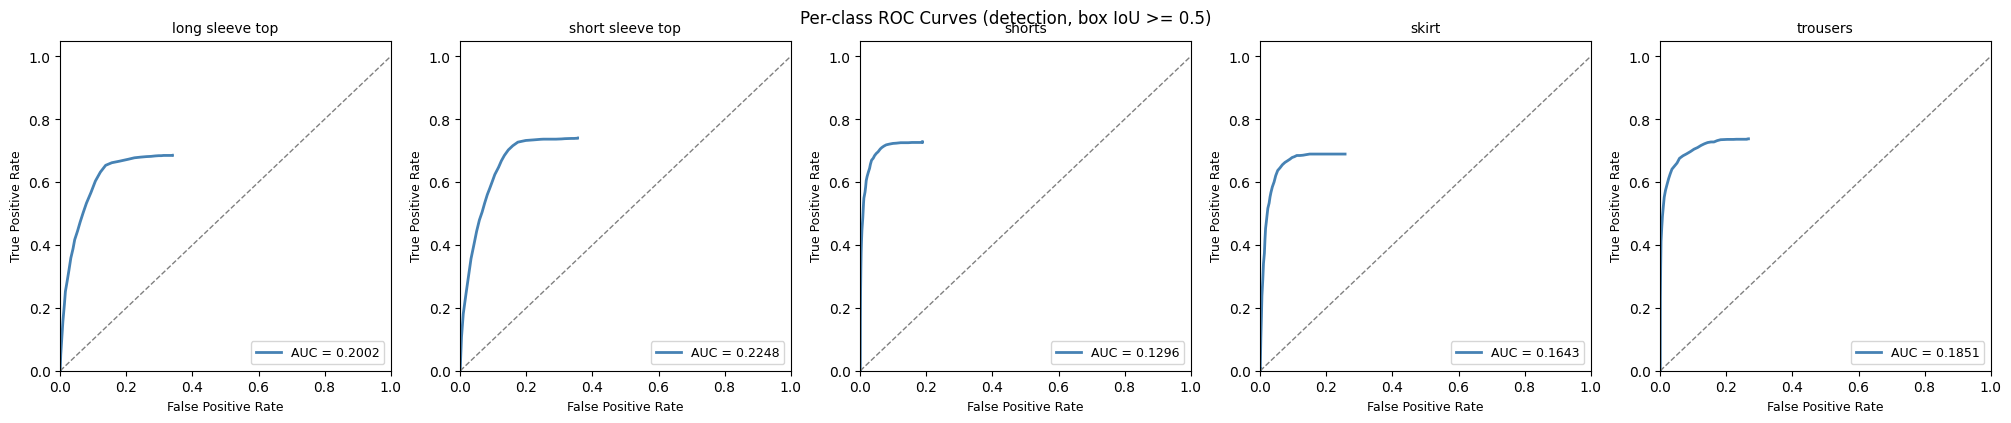

ROC curve plot saved to roc_curves_detection.png

Per-class ROC-AUC (Detection)
  long sleeve top       : 0.2002
  short sleeve top      : 0.2248
  shorts                : 0.1296
  skirt                 : 0.1643
  trousers              : 0.1851
  Macro avg             : 0.1808


In [19]:
from IPython.display import display as ipy_display
import matplotlib.pyplot as plt
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# Per-class ROC — Detection-based (box IoU matching)
#
# Pipeline:
#   1. For each image, extract GT instances and predicted instances via
#      postprocess_mask() — already defined in Cell 19.
#      GT  instances: postprocess_mask(gt_mask,   prob_map=None)  → score = area proxy
#      DT  instances: postprocess_mask(pred_mask, prob_map=prob_map) → score = mean softmax
#   2. Sweep confidence thresholds 0→1.
#      At each threshold, keep only DT instances with score >= thresh.
#   3. Greedy IoU matching (descending score) at IoU >= 0.5 → TP / FP / FN.
#   4. TN = GT boxes of OTHER classes (standard proxy when true TN is undefined).
#   5. TPR = TP/(TP+FN),  FPR = FP/(FP+TN)  → one ROC point per threshold.
#   6. AUC via np.trapz on the sorted curve.
#
# All helper functions (postprocess_mask, box_iou) are already defined above.
# All data (gt_masks_all, pred_masks_all, prob_maps_all) come from Cell 20.
# ══════════════════════════════════════════════════════════════════════════════

IOU_THRESHOLD = 0.5
thresholds    = np.linspace(0, 1, 50)

# ── Build per-image instance cache ONCE (avoids re-running connected components
#    50× per image inside the threshold sweep — major speedup) ─────────────────
print("Building instance cache ...")
cache = []
for gt_mask, pred_mask, prob_map in zip(gt_masks_all, pred_masks_all, prob_maps_all):
    gt_insts   = postprocess_mask(gt_mask,   prob_map=None)      # score = area proxy
    pred_insts = postprocess_mask(pred_mask, prob_map=prob_map)  # score = mean softmax
    cache.append({"gt": gt_insts, "pred": pred_insts})

print(f"Cache ready — {len(cache)} images")

# ── Per-class ROC sweep ───────────────────────────────────────────────────────
n_cls = NUM_CLASSES - 1   # foreground classes only
fig, axes = plt.subplots(1, n_cls, figsize=(4 * n_cls, 4), constrained_layout=True)
if n_cls == 1:
    axes = [axes]

roc_auc_per_class = {}

for i, cls_idx in enumerate(range(1, NUM_CLASSES)):
    cls_name = idx_to_class[cls_idx]
    all_tpr, all_fpr = [], []

    for thresh in thresholds:
        TP, FP, FN, TN = 0, 0, 0, 0

        for entry in cache:
            gt_cls   = [g for g in entry["gt"]   if g["label"] == cls_idx]
            # Filter predictions by confidence threshold, sort descending
            pred_cls = sorted(
                [p for p in entry["pred"] if p["label"] == cls_idx and p["score"] >= thresh],
                key=lambda x: -x["score"]
            )

            used_gt = set()
            for pred in pred_cls:
                best_iou, best_gi = 0.0, -1
                for gi, gt in enumerate(gt_cls):
                    if gi in used_gt:
                        continue
                    iou = box_iou(pred["bbox"], gt["bbox"])
                    if iou > best_iou:
                        best_iou, best_gi = iou, gi
                if best_iou >= IOU_THRESHOLD and best_gi >= 0:
                    TP += 1
                    used_gt.add(best_gi)
                else:
                    FP += 1

            # Unmatched GT boxes of this class → false negatives
            FN += sum(1 for gi in range(len(gt_cls)) if gi not in used_gt)

            # GT boxes of ALL other foreground classes → true negatives for this class
            TN += sum(1 for g in entry["gt"] if g["label"] != cls_idx)

        TPR = TP / (TP + FN + 1e-16)
        FPR = FP / (FP + TN + 1e-16)
        all_tpr.append(TPR)
        all_fpr.append(FPR)

    all_fpr = np.array(all_fpr)
    all_tpr = np.array(all_tpr)
    idx     = np.argsort(all_fpr)
    all_fpr = all_fpr[idx]
    all_tpr = all_tpr[idx]

    roc_auc_val = float(np.trapz(all_tpr, all_fpr))
    roc_auc_per_class[cls_name] = roc_auc_val

    ax = axes[i]
    ax.plot(all_fpr, all_tpr, color="steelblue", lw=2,
            label=f"AUC = {roc_auc_val:.4f}")
    ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate", fontsize=9)
    ax.set_title(cls_name, fontsize=10)
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle("Per-class ROC Curves (detection, box IoU >= 0.5)", fontsize=12, y=1.02)
plt.savefig("roc_curves_detection.png", dpi=120, bbox_inches="tight")
ipy_display(fig)
plt.close(fig)
print("ROC curve plot saved to roc_curves_detection.png")

print("\nPer-class ROC-AUC (Detection)")
print("=" * 34)
for cls_name, auc_val in roc_auc_per_class.items():
    print(f"  {cls_name:<22}: {auc_val:.4f}")
print("=" * 34)
macro_auc = np.mean(list(roc_auc_per_class.values()))
print(f"  {'Macro avg':<22}: {macro_auc:.4f}")